# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 2 - Visualisations
creation of maps, graphs and more

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")  # folder for saving new dataframes

In [3]:
# Load data sets
# gdf_census = gpd.read_file('data/data_ssi.geojson')
census_boundaries = gpd.read_file('data/ZAEHLBEZIRKOGDPolygon.shp')

In [4]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
gdf_census = gpd.read_file(os.path.join(df_dir,"gdf_census.geojson"))
ugbs_socioecon_census = gpd.read_file(os.path.join(df_dir, "ugbs_socioecon_census.geojson"))
socioecon_districts = gpd.read_file(os.path.join(df_dir, "socioecon_districts.geojson"))
housingprices_district = gpd.read_file(os.path.join(df_dir, "housingprices_district.geojson"))
social_housing = pd.read_csv(os.path.join(df_dir, "social_housing.csv"))
social_housing_gdf = gpd.read_file(os.path.join(df_dir, "social_housing.geojson"))
aptfeatures_social_census = pd.read_csv(os.path.join(df_dir, "aptfeatures_social_census.csv"))
apt_features_final_census = pd.read_csv(os.path.join(df_dir, "apt_features_final_census.csv"))
merged_census = gpd.read_file(os.path.join(df_dir, "merged_census.geojson"))

Skipping field ways: unsupported OGR type: 1


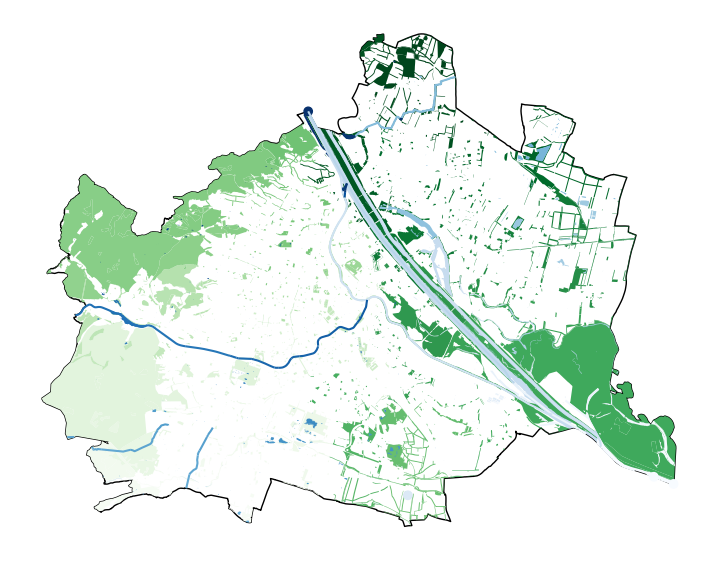

In [5]:
#greens from Open Data Austria, and blues from OSM:

f, ax = plt.subplots(1, 1, figsize=(9, 9))

admin_city.plot(ax=ax, color='none', edgecolor='k')
urban_green_spaces.plot(ax=ax, cmap='Greens')
urban_blue_spaces.plot(ax=ax, cmap='Blues')
ax.axis('off')

plt.savefig("output/vienna_green_blue_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
'avg_income' in merged_census.columns
print(merged_census.crs)

EPSG:31256


In [7]:
merged_census = merged_census.to_crs(epsg=4326)

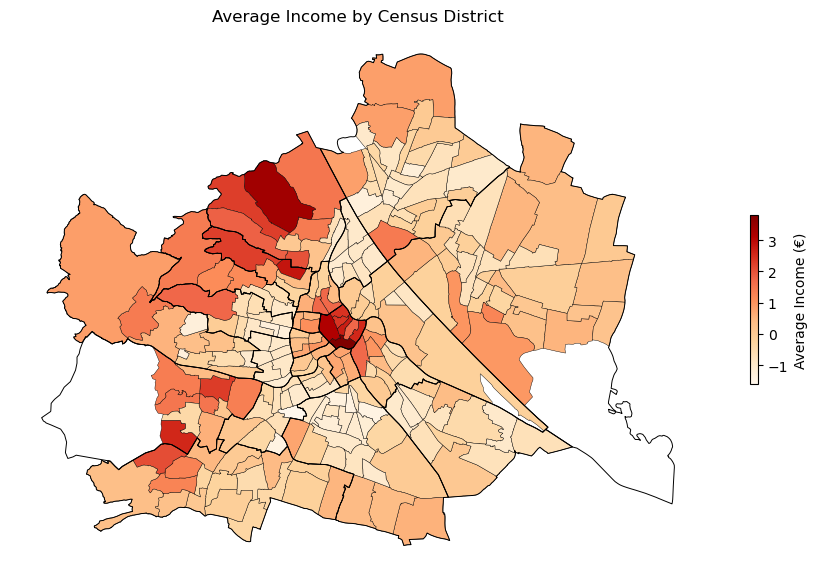

In [8]:
# Shared color scale (replace with a consistent range across all your maps)
vmin = gdf_census['avg_income'].min()
vmax = gdf_census['avg_income'].max()

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

gdf_census.plot(
    column='avg_income',
    cmap='OrRd',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Average Income (€)", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

socioecon_districts.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)

ax.set_title("Average Income by Census District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/avgincome_census_map.png", dpi=300, bbox_inches='tight')
plt.show()


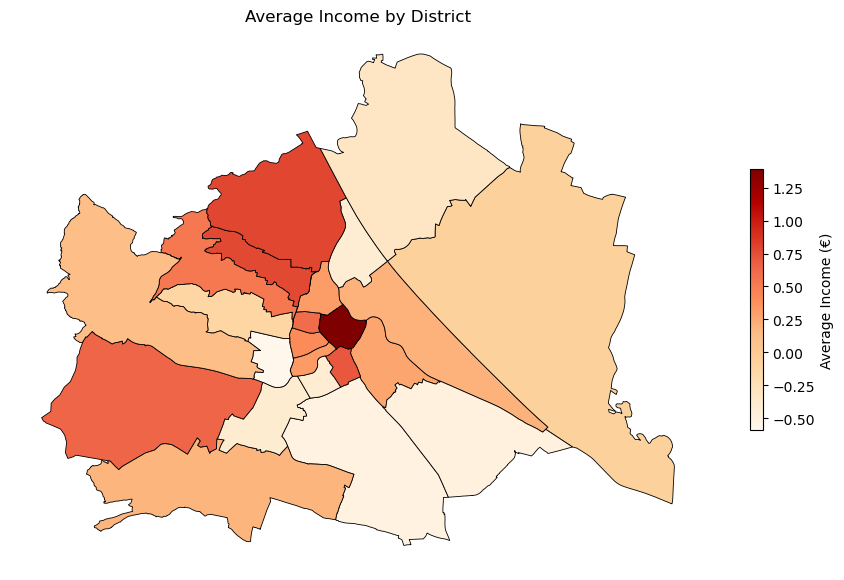

In [9]:
# average income per district
vmin = socioecon_districts['district_avgincome'].min()
vmax = socioecon_districts['district_avgincome'].max()

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

socioecon_districts.plot(
    column='district_avgincome',
    cmap='OrRd',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Average Income (€)", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Average Income by District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/avgincome_district_map.png", dpi=300, bbox_inches='tight')
plt.show()


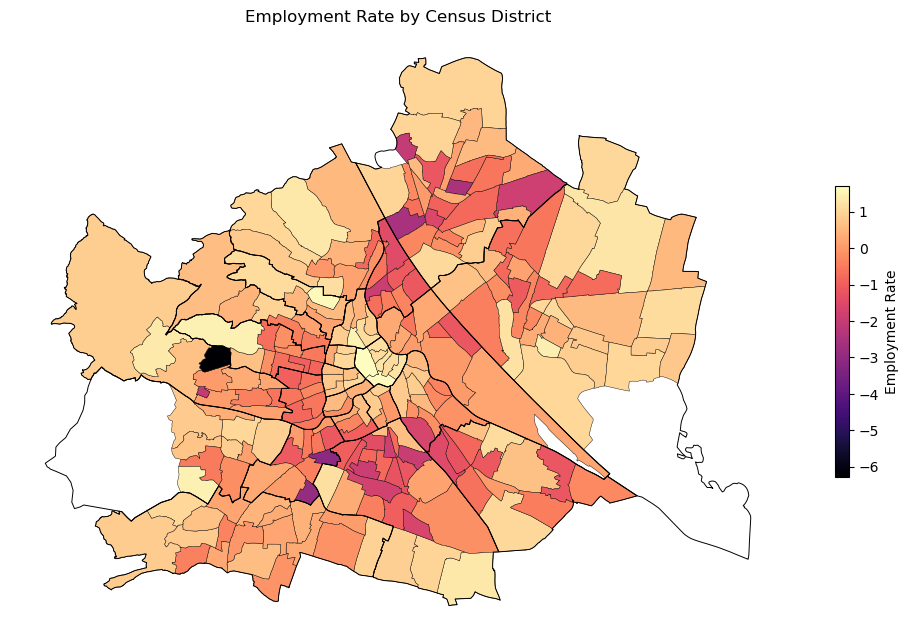

In [10]:
# Plot unemployment rate
vmin = gdf_census['employment'].min()
vmax = gdf_census['employment'].max()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_census.plot(
    column='employment',
    cmap='magma',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Employment Rate", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

socioecon_districts.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)

ax.set_title("Employment Rate by Census District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/employmentrate_census_map.png", dpi=300, bbox_inches='tight')
plt.show()


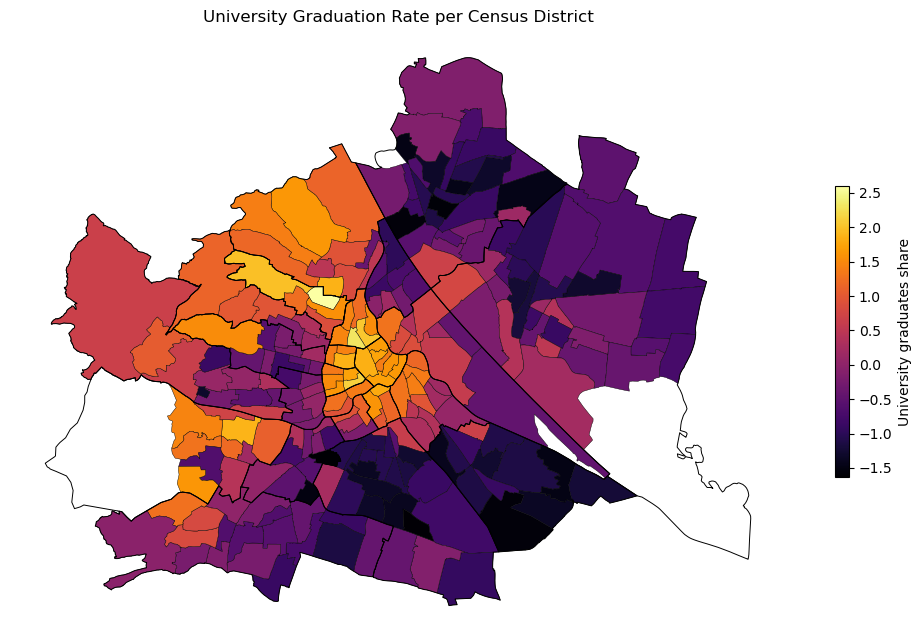

In [11]:
# Plot unigrad rate
vmin = gdf_census['university_share'].min()
vmax = gdf_census['university_share'].max()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_census.plot(
    column='university_share',
    cmap='inferno',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "University graduates share", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

socioecon_districts.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)

ax.set_title("University Graduation Rate per Census District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/unigrad_census_map.png", dpi=300, bbox_inches='tight')
plt.show()

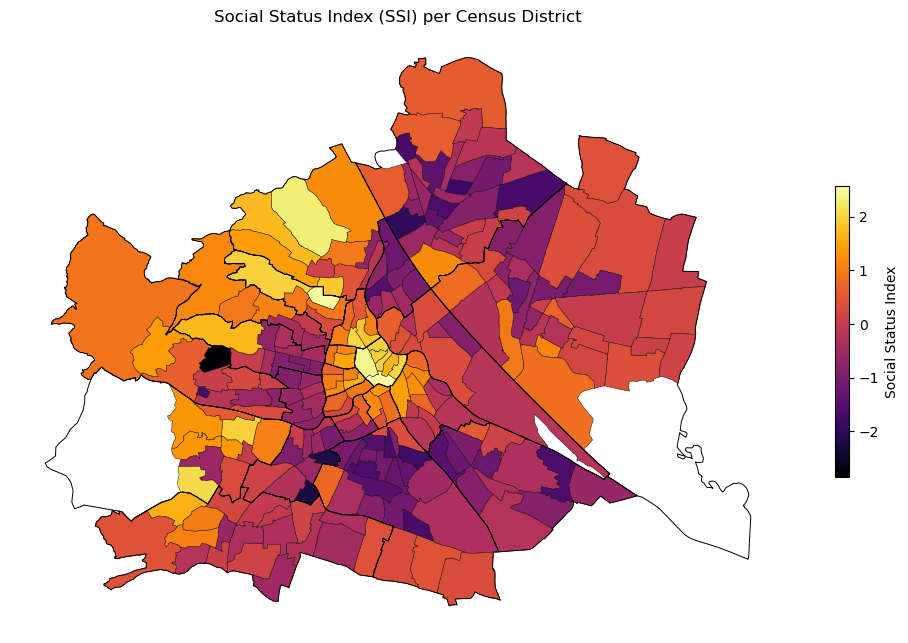

In [12]:
# Plot SSI by census district
vmin = gdf_census['SSI'].min()
vmax = gdf_census['SSI'].max()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_census.plot(
    column='SSI',
    cmap='inferno',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Social Status Index", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

socioecon_districts.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)

ax.set_title("Social Status Index (SSI) per Census District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/ssi_census_map.png", dpi=300, bbox_inches='tight')
plt.show()

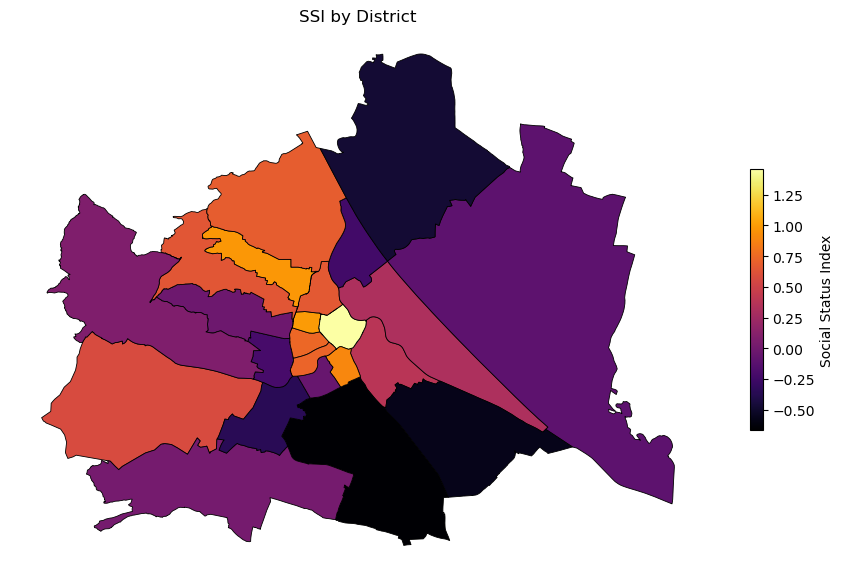

In [13]:
# SSI per district
vmin = socioecon_districts['district_SSI'].min()
vmax = socioecon_districts['district_SSI'].max()

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

socioecon_districts.plot(
    column='district_SSI',
    cmap='inferno',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Social Status Index", 'shrink': 0.3},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("SSI by District", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/ssi_district_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Set shared figure size
figsize = (12, 12)

# Define consistent UGBS overlay function
def overlay_ugbs(ax):
    urban_green_spaces.plot(
        ax=ax,
        cmap='Greens',
        alpha=0.3,
        edgecolor='darkgreen',
        linewidth=0.5
    )
    urban_blue_spaces.plot(
        ax=ax,
        color='blue',
        alpha=0.3,
        edgecolor='darkblue',
        linewidth=0.5
    )
    admin_city.plot(ax=ax, color='none', edgecolor='black', linewidth=1.2)
    socioecon_districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# --- Map 1: SSI ---
fig1, ax1 = plt.subplots(1, 1, figsize=figsize)

gdf_census.plot(
    column='SSI',
    cmap='PuOr',
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Social Status Index", 'shrink': 0.6},
    ax=ax1
)
overlay_ugbs(ax1)
ax1.set_title("SSI & Green/Blue Spaces in Vienna", fontsize=14)
ax1.axis('off')

plt.tight_layout()
plt.savefig("output/ssi_ubgs_census_map.png", dpi=300, bbox_inches='tight')
plt.close(fig1)

# --- Map 2: Average Income ---
fig2, ax2 = plt.subplots(1, 1, figsize=figsize)

gdf_census.plot(
    column='avg_income',
    cmap='OrRd',
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Average Income (€)", 'shrink': 0.6},
    ax=ax2
)
overlay_ugbs(ax2)
ax2.set_title("Average Income & Green/Blue Spaces in Vienna", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.savefig("output/avgincome_ubgs_census_map.png", dpi=300, bbox_inches='tight')
plt.close(fig2)

In [15]:
housingprices_district.head(5)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4132,4043,4423,4462,4821,5593,6159,5327,4799.11,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3369,3315,3827,3860,4111,4729,4460,4215,3812.78,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4553,4755,5405,5833,6043,6332,6336,5929,5551.11,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."
3,Landstraße,3.0,III,"3., Landstraße",III. Landstraße,LANDSTRASSE,III.,03,1030.0,903.0,...,4039,4483,4787,4375,5483,5715,5850,5635,4922.33,"POLYGON ((16.39662 48.20739, 16.39678 48.20656..."
4,Josefstadt,8.0,VIII,"8., Josefstadt",VIII. Josefstadt,JOSEFSTADT,VIII.,08,1080.0,908.0,...,4744,5292,4975,4798,5996,7842,7697,6148,5723.56,"POLYGON ((16.34915 48.21516, 16.35099 48.21497..."


In [16]:
min_row_numb = housingprices_district.loc[housingprices_district["avg_price_years"].idxmin()]
max_row_numb = housingprices_district.loc[housingprices_district["avg_price_years"].idxmax()]

print("\nMIN avg_price_years:")
print(min_row_numb[["BEZNR", "avg_price_years"]])

print("\nMAX avg_price_year:")
print(max_row_numb[["BEZNR", "avg_price_years"]])


MIN avg_price_years:
BEZNR                11.0
avg_price_years    3420.0
Name: 19, dtype: object

MAX avg_price_year:
BEZNR                   1.0
avg_price_years    10787.33
Name: 5, dtype: object


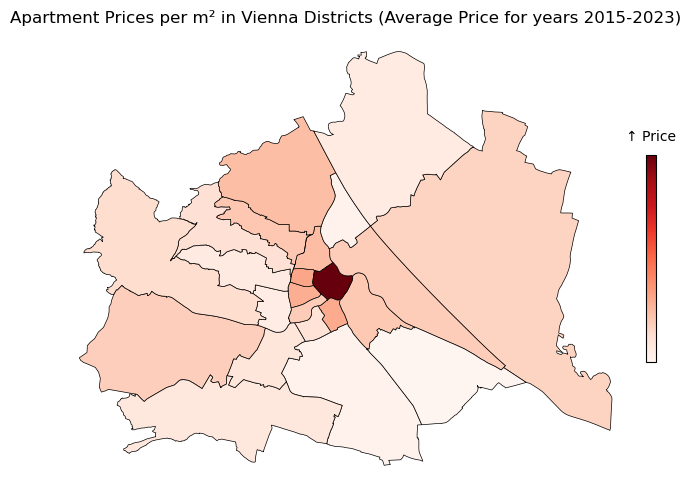

In [17]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot without legend
housing_districts_plot = housingprices_district.plot(
    column='avg_price_years',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False 
)

# Create a scalar mappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=housingprices_district['avg_price_years'].min(),
    vmax=housingprices_district['avg_price_years'].max()
)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm._A = []  # required for matplotlib <3.1

# Adding the colorbar manually
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.3,              
    pad=0.01,                
    orientation='vertical',
    location='right'         
)

# Remove ticks and add title to the colorbar
cbar.ax.set_yticks([])
cbar.ax.set_title('↑ Price', fontsize=10, pad=10)

# Final plot tweaks
ax.set_title("Apartment Prices per m² in Vienna Districts (Average Price for years 2015-2023)", fontsize=12)
ax.axis('off')
plt.savefig("output/prices_district_map.png", dpi=300, bbox_inches='tight')
plt.show()

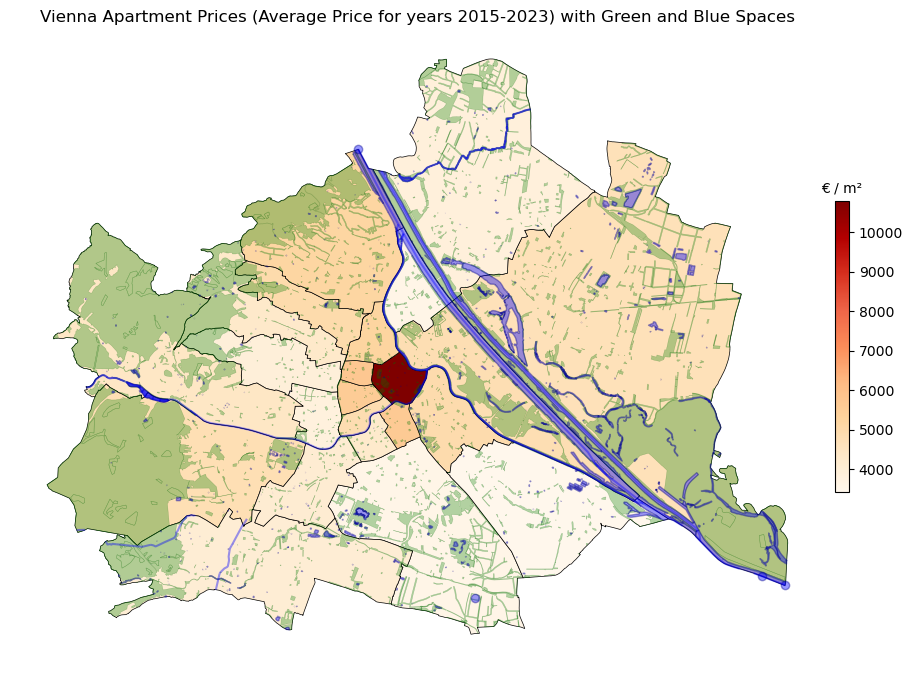

In [18]:
# Setup plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot housing prices as base choropleth
housingprices_district.plot(
    column='avg_price_years',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False  
)

# Overlay green and blue spaces
urban_green_spaces.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)
urban_blue_spaces.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Add colorbar manually
norm = mpl.colors.Normalize(vmin=housingprices_district['avg_price_years'].min(), vmax=housingprices_district['avg_price_years'].max())
sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.01)
cbar.ax.set_title('€ / m²', fontsize=10)

# Title & layout
ax.set_title("Vienna Apartment Prices (Average Price for years 2015-2023) with Green and Blue Spaces", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig("output/prices_ugbs_district_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print(plt.colormaps()) 

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_15279/1639760594.py:33: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


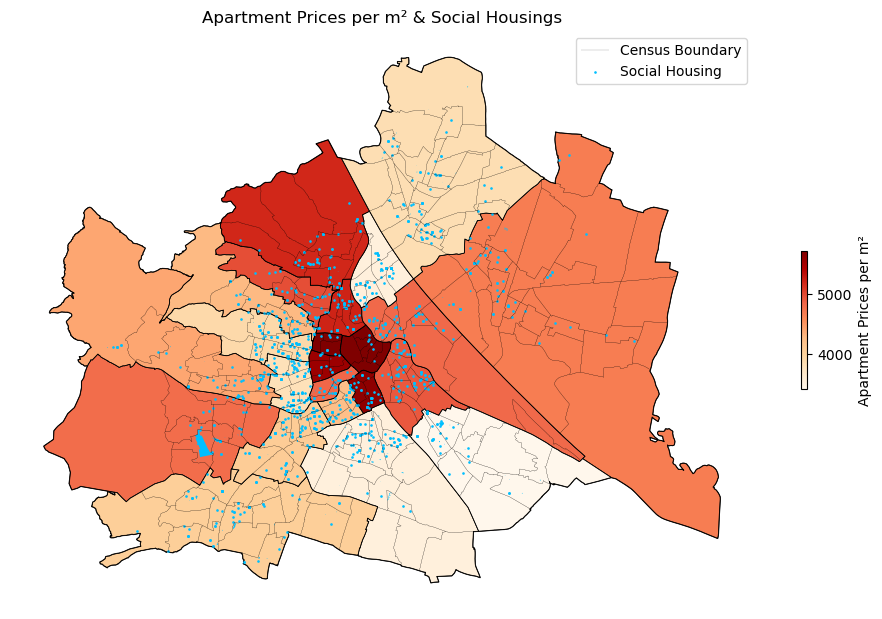

In [20]:
# Cap values above 95th percentile to improve visual differentiation
cap = housingprices_district['avg_price_years'].quantile(0.95)
housingprices_district['price_capped'] = housingprices_district['avg_price_years'].clip(upper=cap)

# average income per district
vmin = housingprices_district['price_capped'].min()
vmax = housingprices_district['price_capped'].max()

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

# Plot administrative and census boundaries
admin_city.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, label="Admin Boundary")
# districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1, label="District Boundary")
census_boundaries.boundary.plot(ax=ax, edgecolor='black', linewidth=0.1, label="Census Boundary")

housingprices_district.plot(
    column='price_capped',
    cmap='OrRd',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Apartment Prices per m²", 'shrink': 0.2},
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

# Plot social housing points (in red, above everything else)
social_housing_gdf.plot(ax=ax, color='deepskyblue', markersize=0.8, label="Social Housing")

ax.set_title("Apartment Prices per m² & Social Housings", fontsize=12)
ax.axis('off')
ax.legend()
plt.savefig("output/socialhousing_aptprices_map.png", dpi=300, bbox_inches='tight')
plt.show()